# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Lotte van Mispelaar
* Username: lkmispelaar
* Student number: S6394973
* Group (AS1, etc.): AS2

-----

In [ ]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

In [7]:
import numpy as np

T = 2.01 # +- 0.02 s
sigma_T = 0.02
L = 1.00 # +- 0.01 m
sigma_L = 0.01

g = (4 * pi**2 * L) / (T**2)

sigma = ((4 * pi**2 / T**2)**2 * sigma_L**2 +(4 * pi**2 * L / (3 * T**3)) * sigma_T**2)**0.5

print(f'Using Taylor expansion the value of g is {g} +-{sigma}')

Using Taylor expansion the value of g is 9.77164367326488 +-0.10097872998689646


$$ g=\frac{4\pi^2 L}{T^2} = \frac{4\pi^2 \cdot 1.00}{2.01^2} = 9.77 m/s^2 $$


$$ \sigma = (\frac{\delta g}{\delta T})^2 \sigma_T^2 + (\frac{\delta g}{\delta L})^2 \sigma_L^2 = (\frac{4\pi^2 \cdot L }{3 T^3})^2 \sigma_T^2 + (\frac{4\pi^2}{T^2})^2 \sigma_L^2 = 0.10 m/s^2$$

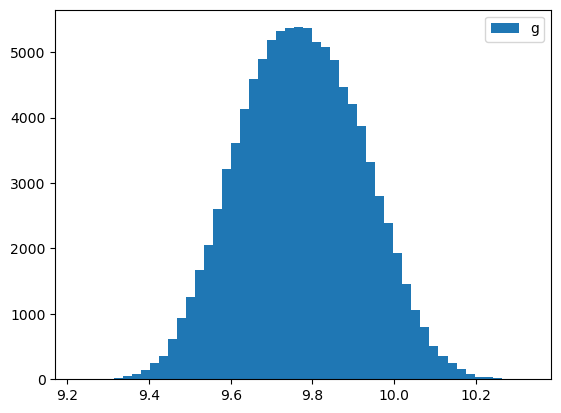

mean of g is 9.772320769073096 and standard deviation of g is 0.1493967438546002 in m/s^2


In [20]:
import numpy as np
from matplotlib import pyplot as plt

# based on the error of T I assume that has been measured by a computer, since the standard deviation is too small for it to happen by hand
# From this I will assume that T has a uniform error distribution, which is common for computers
T = np.random.uniform(1.99, 2.03, 100000)

# For the length, which has an error of 1 cm, I asume a normal distribution is the most fitting. 
# This is because the error seems realistic for hand made measurements
L = np.random.normal(1.00, 0.01, 100000)

# it is important to note that I am merely speculating what the error distribution could look like and everything is very much uncertain.

g = (4 * pi**2 * L) / (T**2)

# plotting it to see if the results even look like they make sense
plt.hist(g, label = 'g', bins = 50)
plt.legend()
plt.show()

print(f'mean of g is {np.mean(g)} and standard deviation of g is {np.std(g)} in m/s^2')

We can see from this that the error using a Monte Carlo error propagation is significantly bigger than merely using the gaussian distribution one. In both cases the literature value of g falls within the error margin, so it doesn't really matter in this case, but it does mean that the error assuming the normal distribution can give a skewed view of the error.

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [30]:
import numpy as np

def solution(coefficients):
    sol = np.roots(coefficients)
    return sol

def eq(a, b, c, solution):
    f = a * solution**2 + b * solution + c
    return f
a = int(input('a ='))
b = int(input('b ='))
c = int(input('c ='))
coefficients = [a, b, c]
print(f'The equation becomes x = (-{b} +-sqrt({b**2 -4*c*a}))/(2*{a})')

if len(solution(coefficients)) == 1:
    print(f'for the equation {a}x^2 + {b}x + {c} the solution is x = {float(solution(coefficients)[0])}')
    
    def eq(a, b, c, solution):
        f = a * solution(coefficients)**2 + b * solution(coefficients) + c
        return f
    print(f'Plugging the value into the original equation gives {eq}')

else:
    print(f'for the equation {a}x^2 + {b}x + {c} the solutions are {solution(coefficients)[0]} and {solution(coefficients)[1]}')
    x1 = solution(coefficients)[0]
    x2 = solution(coefficients)[1]
    def eq(a, b, c, x1):
        f = a * x1**2 + b * x1 + c
        return f
    def eq2(a, b, c, x2):
        f = a * x1**2 + b * x1 + c
        return f
        
    print(f'Plugging the values into the original equation gives {eq(a, b, c, x1)} and {eq(a, b, c, x2)}')
print('The plugged in values give a small enough result to be attributed to rounding errors from numpy')


a = 1
b = 2
c = 3


The equation becomes x = (-2 +-sqrt(-8))/(2*1)
for the equation 1x^2 + 2x + 3 the solutions are (-0.9999999999999999+1.414213562373095j) and (-0.9999999999999999-1.414213562373095j)
Plugging the values into the original equation gives (4.440892098500626e-16+4.440892098500626e-16j) and (4.440892098500626e-16-4.440892098500626e-16j)
The plugged in values give a small enough result to be attributed to rounding errors from numpy


In [9]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

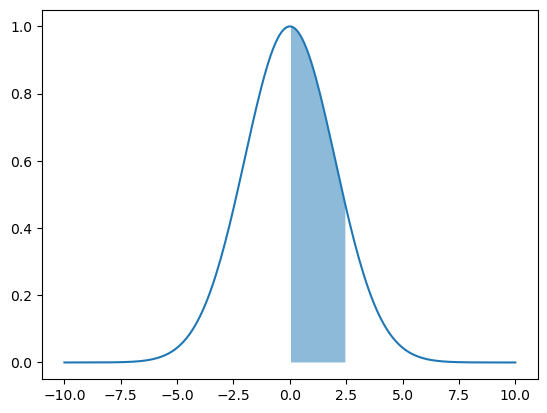

area between x = 0 and x = 2.5: 1.9769788548675902
using numpy: 5.013253675146261
using given integral: 5.0132565492620005


In [80]:
import numpy as np
from matplotlib import pyplot as plt
import scipy

def gauss(x):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

A = 1.0
x0 = 0.0
sigma = 2.0
z0 = 0.0
x = np.linspace(-10, 10, 200)

plt.plot(x, gauss(x))
plt.fill_between(x, gauss(x), 0,  
                 where = (x >= 0) & (x <= 2.5),
                alpha = 0.5)
plt.show()

# numpy to integrate
print('area between x = 0 and x = 2.5:', scipy.integrate.quad(gauss, 0, 2.5)[0])
print('using numpy:', scipy.integrate.quad(gauss, -10, 10)[0])

# given integral
print('using given integral:', A * sigma * (2 * np.pi)**0.5)

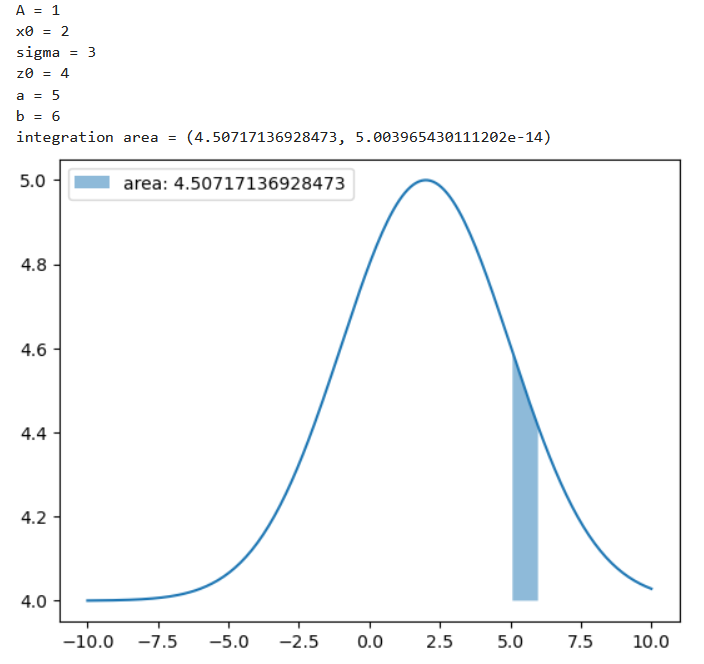

https://github.com/LvanMis/PROGNUM-repo/tree/main/Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [96]:
from numpy import sin, cos, exp, pi
import scipy as sy

def f(x):
    return x**4 + exp(sin(x) + cos(x))

print('using scipy:', eval('sy.integrate.quad(f, 0, pi)')[0])

x = np.linspace(0, pi, 1000)
def y(x):
    return (pi - 0)/1000 * sum(f(x))

print('using monte carlo integration with 1000 samples:', y(x))

using scipy: 68.72932272689113
using monte carlo integration with 1000 samples: 68.81855054519552


https://github.com/LvanMis/PROGNUM-repo/tree/main/Task4

In [153]:
import sympy as sp
from numpy import pi, cos, exp, sin
import numpy as np

sp.sympify((pi - 0)/1000 * sum(x**4 + exp(sin(x) + cos(x))), evaluate = True)


68.8185505451955

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

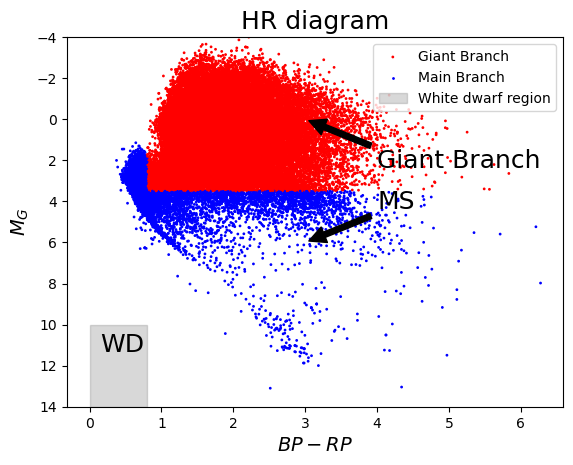

In [171]:
from astropy.io import fits
import numpy as np
import random
from matplotlib import pyplot as plt


# Open the FITS file
hdul = fits.open(r'APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

# filtering conditions
condition = np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])
data = data[~condition]
condition = np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])
data = data[~condition]
condition = np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])
data = data[~condition]
condition = data['STARFLAG'] == 0
data = data[condition]
condition = data['ASPCAPFLAG'] == 0
data = data[condition]
condition = data['SNR'] > 10
data = data[condition]
condition = data['GAIAEDR3_PARALLAX']/ data['GAIAEDR3_PARALLAX_ERROR'] > 5
data = data[condition]

# 
N = data.size
idx = np.random.choice(N, int(0.8*N), replace = False)
data = data[idx]

# creating the graphs

x = data['GAIAEDR3_PHOT_BP_MEAN_MAG'] - data['GAIAEDR3_PHOT_RP_MEAN_MAG']
y = (data['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5 * np.log10(data['GAIAEDR3_PARALLAX']/1000) + 5)

col = np.where(x < 0.8,'b',np.where(y>3.5,'b','r'))

plt.scatter(x, y, s = 1, color = col, label = 'Giant Branch')

plt.yticks([x for x in range(14, -5, -2)])
plt.ylim(14, -4)

# text
plt.annotate(r'Giant Branch', xy=(3, 0), xytext=(4, 2),
             arrowprops=dict(color='black', shrink=0.05),
             fontsize=18, color='black', verticalalignment='center')
plt.annotate(r'MS', xy=(3, 6), xytext=(4, 4),
             arrowprops=dict(color='black', shrink=0.05),
             fontsize=18, color='black', verticalalignment='center')
plt.annotate(r'WD', xy=(0.15, 11), xytext=(0.15, 11),
             fontsize=18, color='black', verticalalignment='center')
plt.scatter(3, 5, s = 1, label = "Main Branch", color = 'blue')

# White dwarfs
line1 = [0.8, 0.8, 0, 0]
line2 = [14, 10, 10, 14]
plt.fill(line1, line2, color = "gray", alpha = 0.3, label ="White dwarf region")
plt.legend(loc = "upper right")
plt.xlabel("$BP-RP$", fontsize = 14)
plt.ylabel("$M_G$", fontsize = 14)
plt.title("HR diagram", fontsize = 18)
plt.show()

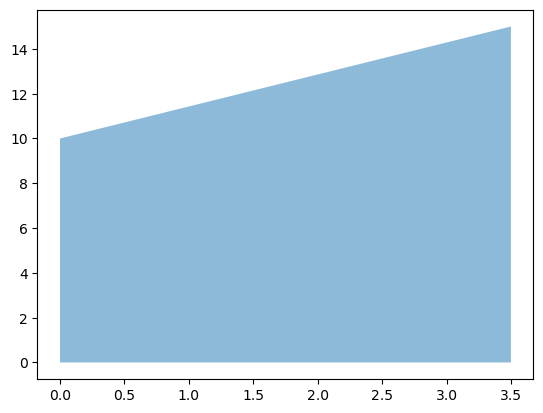

In [67]:
y_dwarf = [15, 15, 10, 10]
x_dwarf = [3.5, 3.5, 0, 0]
plt.fill_between(x_dwarf, y_dwarf,
                alpha = 0.5)

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")